In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats


In [2]:
ticker = ["RELIANCE.NS","HDFCBANK.NS","TCS.NS","INFY.NS","WIPRO.NS"]
data = yf.download(ticker,start = "2019-1-1",end = "2024-1-1")
prices = data["Close"]
print(prices.shape)
print(prices.head())


[*********************100%***********************]  5 of 5 completed

(1235, 5)
Ticker      HDFCBANK.NS     INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS
Date                                                                     
2019-01-01   504.392487  553.448364   498.490570  1582.165894  112.147354
2019-01-02   499.790283  556.777222   491.998260  1599.212036  111.769691
2019-01-03   495.868958  556.860413   485.928314  1579.796265  111.752518
2019-01-04   497.195587  550.119812   488.551910  1560.588745  111.392029
2019-01-07   497.946960  558.982605   491.264496  1578.091797  111.323364


In [3]:
#log return
log_returns  = np.log(prices/prices.shift(1))
log_returns = log_returns.dropna()

print(log_returns.shape)
print(log_returns.head())


(1234, 5)
Ticker      HDFCBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  WIPRO.NS
Date                                                              
2019-01-02    -0.009166  0.005997    -0.013109  0.010716 -0.003373
2019-01-03    -0.007877  0.000149    -0.012414 -0.012215 -0.000154
2019-01-04     0.002672 -0.012179     0.005385 -0.012233 -0.003231
2019-01-07     0.001510  0.015982     0.005537  0.011153 -0.000617
2019-01-08    -0.008358 -0.002460    -0.000091 -0.002295  0.004001


In [6]:
#log return
log_returns = np.log(prices/prices.shift(1))
log_returns = log_returns.dropna()

print(log_returns.shape)
print(log_returns.head()) 

#rolling volatility window 30
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)

annual_return = log_returns.mean() * 252

annual_vol = log_returns.std() * np.sqrt(252)

#risk free rate 

rf = 0.06

#sharpe ratio for each stock 

sr = (annual_return - rf)/annual_vol

print("annualised return:")
print(annual_return.round(4))

print("\nannualised volatility:")
print(annual_vol.round(4))

print("\nsharpe ratio:")
print(sr.round(4))

(1234, 5)
Ticker      HDFCBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  WIPRO.NS
Date                                                              
2019-01-02    -0.009166  0.005997    -0.013109  0.010716 -0.003373
2019-01-03    -0.007877  0.000149    -0.012414 -0.012215 -0.000154
2019-01-04     0.002672 -0.012179     0.005385 -0.012233 -0.003231
2019-01-07     0.001510  0.015982     0.005537  0.011153 -0.000617
2019-01-08    -0.008358 -0.002460    -0.000091 -0.002295  0.004001
annualised return:
Ticker
HDFCBANK.NS    0.1022
INFY.NS        0.1971
RELIANCE.NS    0.1931
TCS.NS         0.1640
WIPRO.NS       0.1380
dtype: float64

annualised volatility:
Ticker
HDFCBANK.NS    0.2689
INFY.NS        0.2892
RELIANCE.NS    0.3032
TCS.NS         0.2480
WIPRO.NS       0.2808
dtype: float64

sharpe ratio:
Ticker
HDFCBANK.NS    0.1568
INFY.NS        0.4739
RELIANCE.NS    0.4389
TCS.NS         0.4196
WIPRO.NS       0.2777
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

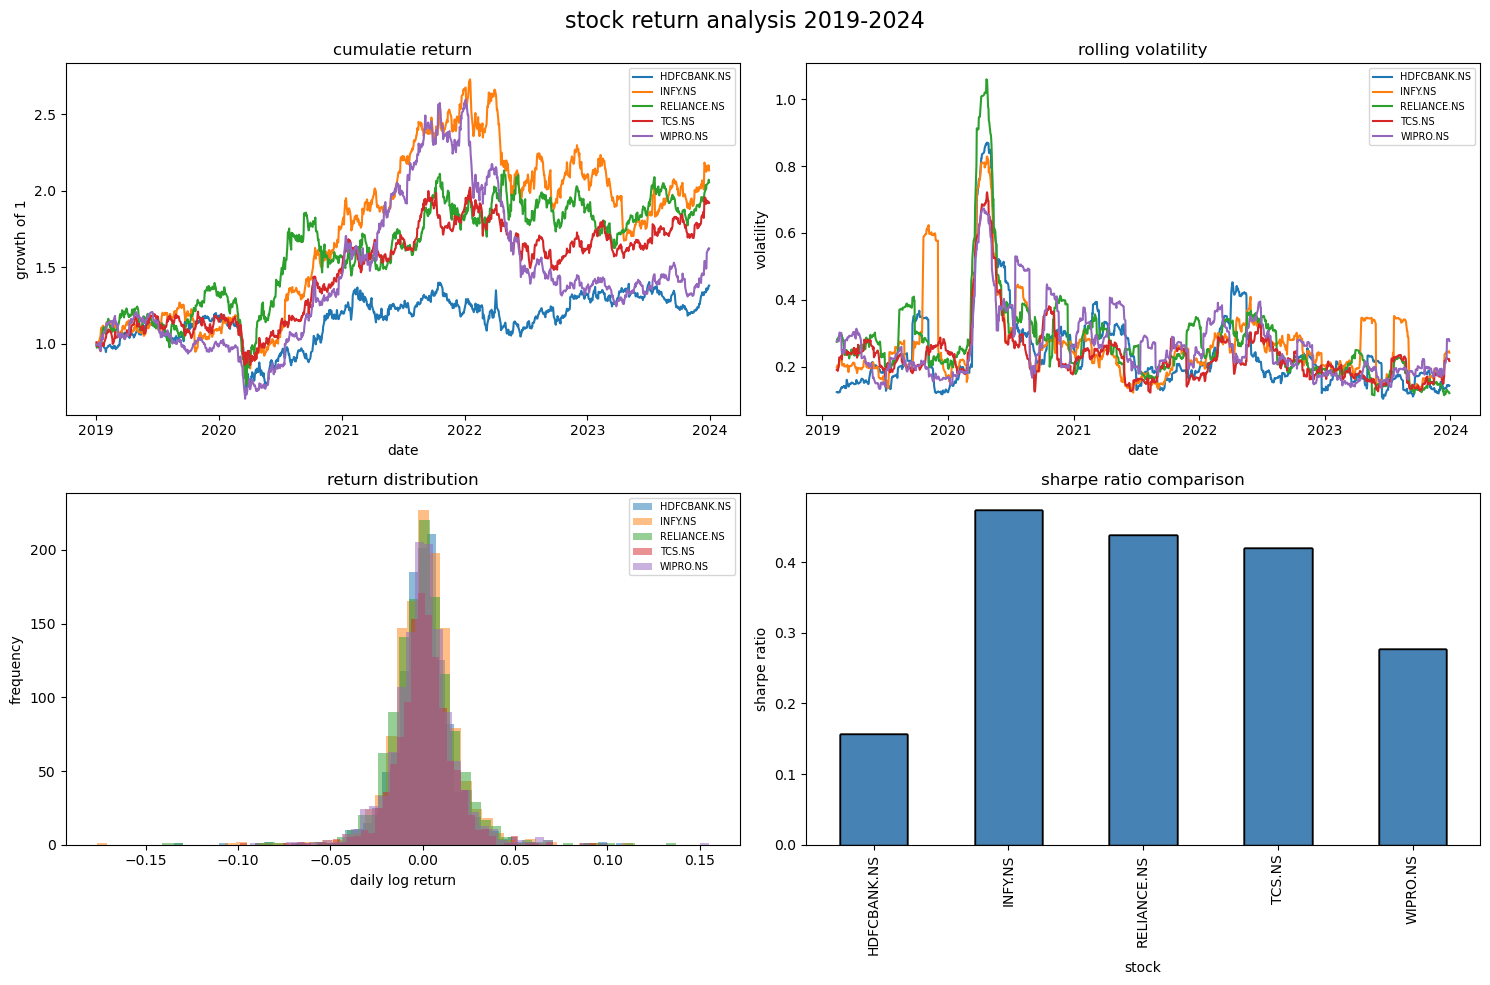

In [20]:
fig,axes = plt.subplots(2,2, figsize=(15,10))
fig.suptitle("stock return analysis 2019-2024",fontsize=16)

#cumulative retuurn
cumulative_return = (1+log_returns).cumprod()

for ticker in log_returns.columns:
    axes[0,0].plot(cumulative_return.index,
                  cumulative_return[ticker],label =ticker)
    axes[0,0].set_title('cumulatie return')
    axes[0,0].set_xlabel('date')
    axes[0,0].set_ylabel('growth of 1')
    axes[0,0].legend(fontsize = 7)



for ticker in log_returns.columns:
    axes[0,1].plot(rolling_vol.index,rolling_vol[ticker],label = ticker)
    axes[0,1].set_title('rolling volatility')
    axes[0,1].set_xlabel('date')
    axes[0,1].set_ylabel('volatility')
    axes[0,1].legend(fontsize =7)


for ticker in log_returns.columns:
    axes[1,0].hist(log_returns[ticker],
                   bins = 50,
                   alpha = 0.5,
                   label = ticker)

    axes[1,0].set_title("return distribution")
    axes[1,0].set_xlabel("daily log return")
    axes[1,0].set_ylabel("frequency") 
    axes[1,0].legend(fontsize = 7) 


for tickker in log_returns.columns:
    sr.plot(kind = 'bar', ax = axes[1,1], color = "steelblue", edgecolor = "black")
    axes[1,1].set_title("sharpe ratio comparison")
    axes[1,1].set_xlabel("stock")
    axes[1,1].set_ylabel("sharpe ratio")


plt.tight_layout()
plt.show
    
                
    
                        


## Project Summary — Stock Return Analyzer

### Data
- 5 NSE stocks: RELIANCE, TCS, HDFCBANK, INFY, WIPRO
- Period: January 2019 to January 2024
- 1234 trading days

### Key Findings
- INFY had the highest Sharpe ratio (0.47) — best return per unit of risk
- HDFCBANK had the lowest Sharpe ratio (0.16) — worst risk-adjusted performance
- RELIANCE was the most volatile stock (30.32% annual volatility)
- All Sharpe ratios below 1 — partly explained by COVID crash in 2020
- Return distributions show excess kurtosis — fatter tails than normal distribution
- COVID spike clearly visible in rolling volatility chart — reached 100% annualised volatility

### Tools Used
Python, Pandas, NumPy, Matplotlib, yFinance